# RouteOpt: Numerical Optimization for Shortest Path and Cost Reduction

## Mini Project Overview
This notebook studies the shortest-path problem in a weighted grid graph using two approaches:

1. **Dijkstra's algorithm** as the classical graph-theoretic baseline  
2. **ADMM-based constrained optimization** using a flow formulation

The project objective is to:
- model route selection as an optimization problem,
- minimize total travel cost,
- enforce flow-conservation constraints,
- compare a numerical optimization approach with the classical shortest-path baseline.

---

## Problem Statement
Given a weighted graph, a source node, and a destination node, the goal is to find a valid route with minimum total cost.  
This is relevant in:
- transportation and delivery routing,
- logistics planning,
- communication-network routing,
- robot path planning.

We formulate the route problem as:

\[
\min_x c^T x
\]

subject to flow conservation:

\[
Bx = b, \qquad 0 \le x \le 1
\]

where:
- \(x\) is the edge-selection / edge-flow vector,
- \(c\) is the edge-cost vector,
- \(B\) is the node-edge incidence matrix,
- \(b\) encodes source and destination flow demands.


In [1]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)


## Graph Construction

We create an undirected weighted grid graph.  
Each edge cost is randomly generated in a fixed range to simulate route/travel cost.


In [3]:
Adj = Dict[int, List[Tuple[int, float]]]

def add_edge(adj: Adj, u: int, v: int, w: float, undirected: bool = False) -> None:
    adj.setdefault(u, []).append((v, w))
    adj.setdefault(v, [])
    if undirected:
        adj[v].append((u, w))

def make_grid_graph(n: int, seed: int = 42, low: float = 1.0, high: float = 9.0):
    rng = np.random.default_rng(seed)
    adj = {}
    coords = {}

    def node_id(x: int, y: int) -> int:
        return y * n + x

    for y in range(n):
        for x in range(n):
            u = node_id(x, y)
            coords[u] = (x, y)
            adj.setdefault(u, [])

            if x + 1 < n:
                v = node_id(x + 1, y)
                w = float(rng.uniform(low, high))
                add_edge(adj, u, v, w, undirected=True)

            if y + 1 < n:
                v = node_id(x, y + 1)
                w = float(rng.uniform(low, high))
                add_edge(adj, u, v, w, undirected=True)

    return adj, coords


In [4]:
def plot_grid(coords, path=None, title="Grid Graph"):
    xs = [coords[i][0] for i in coords]
    ys = [coords[i][1] for i in coords]

    plt.figure(figsize=(7, 7))
    plt.scatter(xs, ys, s=10, alpha=0.35)

    if path is not None and len(path) > 1:
        px = [coords[i][0] for i in path]
        py = [coords[i][1] for i in path]
        plt.plot(px, py, linewidth=3)
        plt.scatter([px[0]], [py[0]], s=90, marker="o", label="Source")
        plt.scatter([px[-1]], [py[-1]], s=110, marker="X", label="Target")
        plt.legend()

    plt.title(title)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.grid(True, alpha=0.2)
    plt.show()


## Baseline Method: Dijkstra's Algorithm

Dijkstra's algorithm gives the exact shortest path in a graph with non-negative edge weights.  
We use it as the benchmark for evaluating the optimization-based solution.


In [5]:
def dijkstra(adj: Adj, source: int, target: int):
    dist = {u: float("inf") for u in adj}
    parent = {source: None}
    dist[source] = 0.0
    pq = [(0.0, source)]

    while pq:
        d, u = heapq.heappop(pq)
        if d != dist[u]:
            continue
        if u == target:
            break

        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                parent[v] = u
                heapq.heappush(pq, (nd, v))

    path = []
    cur = target
    while cur is not None:
        path.append(cur)
        cur = parent.get(cur)

    path.reverse()
    return dist[target], path


## Optimization Formulation

To solve the shortest-path problem numerically, we build the node-edge incidence matrix and cost vector.

### Decision Variable
For each directed edge \(e\), define:
- \(x_e = 1\) if the edge is selected,
- \(x_e = 0\) otherwise.

In practice, ADMM solves a relaxed version with:
\[
0 \le x_e \le 1
\]

### Objective
\[
\min \sum_e c_e x_e = c^T x
\]

### Constraints
\[
Bx = b
\]

where:
- the source sends one unit of flow,
- the target receives one unit of flow,
- every intermediate node preserves flow balance.


In [6]:
@dataclass
class Edge:
    u: int
    v: int
    w: float

def build_incidence(adj: Adj, source: int, target: int):
    nodes = sorted(adj.keys())
    node_to_i = {u: i for i, u in enumerate(nodes)}

    edges: List[Edge] = []
    for u in nodes:
        for v, w in adj[u]:
            edges.append(Edge(u, v, float(w)))

    n = len(nodes)
    m = len(edges)

    B = np.zeros((n, m), dtype=np.float64)
    c = np.zeros(m, dtype=np.float64)

    for k, e in enumerate(edges):
        B[node_to_i[e.u], k] = 1.0
        B[node_to_i[e.v], k] = -1.0
        c[k] = e.w

    b = np.zeros(n, dtype=np.float64)
    b[node_to_i[source]] = 1.0
    b[node_to_i[target]] = -1.0

    return B, c, b, edges, nodes


## ADMM Solver

We solve:

\[
\min c^T x \quad \text{subject to } Bx=b, \; 0\le x\le 1
\]

using ADMM. The algorithm alternates between:

- **x-update**: box-constrained optimization step  
- **z-update**: projection onto the feasible flow set \(Bx=b\)  
- **u-update**: dual-variable update

We also track:
- objective value,
- feasibility residual \(\|Bz-b\|\),
- primal residual,
- dual residual.


In [7]:
def admm_shortest_path(B, c, b, iters: int = 2500, rho: float = 50.0):
    n, m = B.shape

    x = np.zeros(m, dtype=np.float64)
    z = np.zeros(m, dtype=np.float64)
    u = np.zeros(m, dtype=np.float64)

    BBt_inv = np.linalg.pinv(B @ B.T + 1e-8 * np.eye(n))

    obj_hist = []
    feas_hist = []
    primal_hist = []
    dual_hist = []

    z_prev = z.copy()

    for _ in range(iters):
        # x-update
        x = np.clip((z - u) - (c / rho), 0.0, 1.0)

        # z-update: projection onto Bz = b
        y = x + u
        z = y - B.T @ (BBt_inv @ ((B @ y) - b))

        # u-update
        u = u + (x - z)

        # diagnostics
        obj_hist.append(float(c @ x))
        feas_hist.append(float(np.linalg.norm(B @ z - b, 2)))
        primal_hist.append(float(np.linalg.norm(x - z, 2)))
        dual_hist.append(float(rho * np.linalg.norm(z - z_prev, 2)))
        z_prev = z.copy()

    return z, obj_hist, feas_hist, primal_hist, dual_hist


## Path Extraction from Optimized Flow

ADMM returns a feasible flow vector.  
To visualize the route, we reconstruct a source-to-target path by following the strongest positive outgoing flow at each node.


In [8]:
def extract_path_from_flow(edges: List[Edge], flow: np.ndarray, source: int, target: int, max_steps: int = 10000):
    outgoing = {}
    for e, val in zip(edges, flow):
        if val > 1e-8:
            outgoing.setdefault(e.u, []).append((e.v, float(val), e.w))

    for u in outgoing:
        outgoing[u].sort(key=lambda t: (-t[1], t[2]))

    path = [source]
    cur = source
    visited = {source}
    steps = 0

    while cur != target and steps < max_steps:
        steps += 1
        candidates = outgoing.get(cur, [])

        nxt = None
        for v, val, w in candidates:
            if v not in visited or v == target:
                nxt = v
                break

        if nxt is None and candidates:
            nxt = candidates[0][0]

        if nxt is None:
            break

        path.append(nxt)
        cur = nxt
        visited.add(cur)

    return path

def path_cost(adj: Adj, path: List[int]) -> float:
    total = 0.0
    for a, b in zip(path, path[1:]):
        for v, w in adj[a]:
            if v == b:
                total += w
                break
    return total


## Run Experiment

In [9]:
# Problem setup
n = 10
adj, coords = make_grid_graph(n=n, seed=42)
source, target = 0, n * n - 1

# Dijkstra baseline
dj_cost, dj_path = dijkstra(adj, source, target)

# ADMM optimization
B, c, b, edges, nodes = build_incidence(adj, source, target)
flow, obj_hist, feas_hist, primal_hist, dual_hist = admm_shortest_path(
    B, c, b, iters=2500, rho=50.0
)
opt_path = extract_path_from_flow(edges, flow, source, target)
opt_cost = path_cost(adj, opt_path)

print(f"Source node      : {source}")
print(f"Target node      : {target}")
print(f"Dijkstra cost    : {dj_cost:.4f}")
print(f"ADMM path cost   : {opt_cost:.4f}")
print(f"Dijkstra path len: {len(dj_path)}")
print(f"ADMM path len    : {len(opt_path)}")
print(f"Final feasibility residual: {feas_hist[-1]:.6e}")


Source node      : 0
Target node      : 99
Dijkstra cost    : 68.5511
ADMM path cost   : 68.5511
Dijkstra path len: 19
ADMM path len    : 19
Final feasibility residual: 3.475187e-08


In [10]:
# Comparison summary
cost_gap = abs(opt_cost - dj_cost)

print("=== RouteOpt Comparison Summary ===")
print(f"Dijkstra shortest cost : {dj_cost:.4f}")
print(f"ADMM extracted cost    : {opt_cost:.4f}")
print(f"Absolute cost gap      : {cost_gap:.6f}")
print(f"Objective (last iter)  : {obj_hist[-1]:.4f}")
print(f"Primal residual        : {primal_hist[-1]:.6e}")
print(f"Dual residual          : {dual_hist[-1]:.6e}")


=== RouteOpt Comparison Summary ===
Dijkstra shortest cost : 68.5511
ADMM extracted cost    : 68.5511
Absolute cost gap      : 0.000000
Objective (last iter)  : 68.5511
Primal residual        : 6.259270e-08
Dual residual          : 5.041603e-07


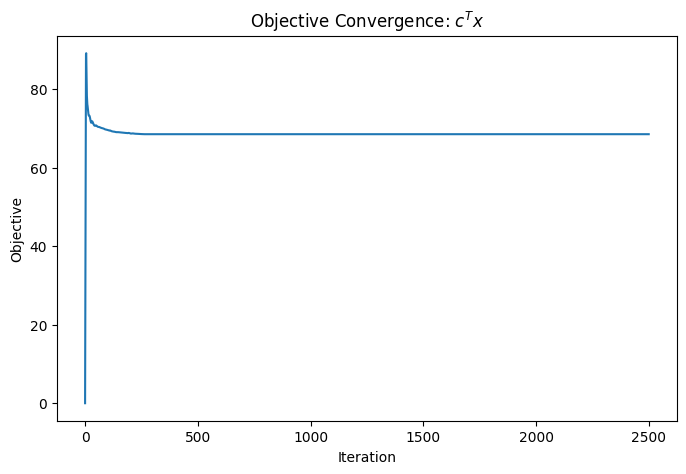

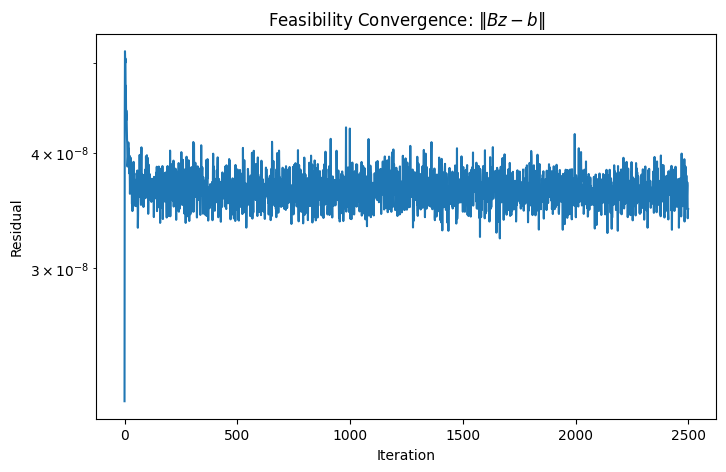

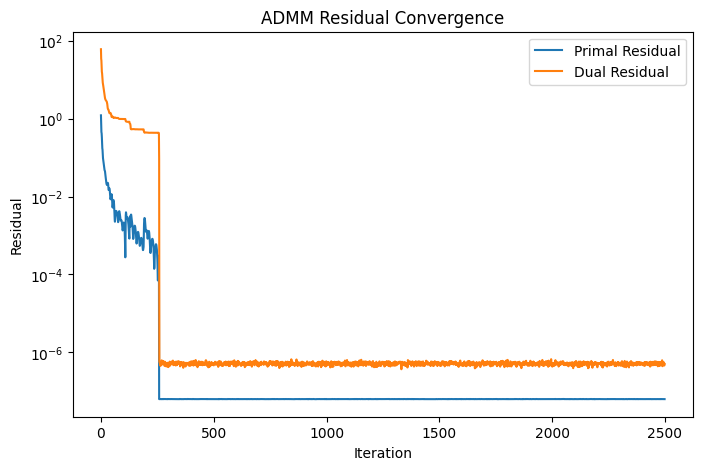

In [11]:
# Convergence plots
plt.plot(obj_hist)
plt.title("Objective Convergence: $c^T x$")
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.show()

plt.semilogy(feas_hist)
plt.title("Feasibility Convergence: $\|Bz-b\|$")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.show()

plt.semilogy(primal_hist, label="Primal Residual")
plt.semilogy(dual_hist, label="Dual Residual")
plt.title("ADMM Residual Convergence")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.legend()
plt.show()


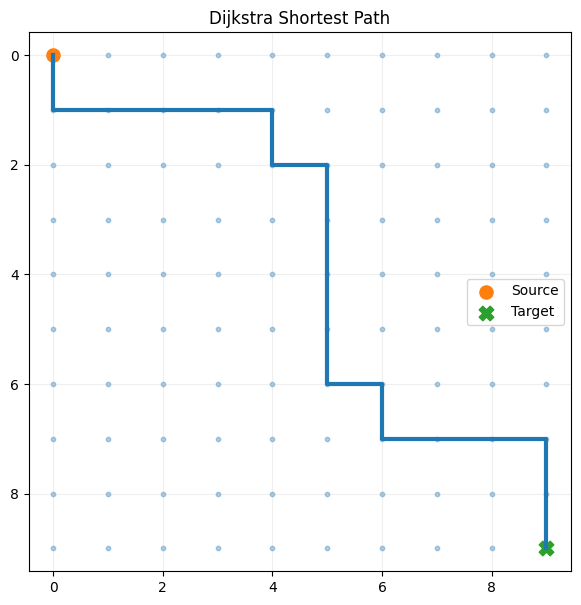

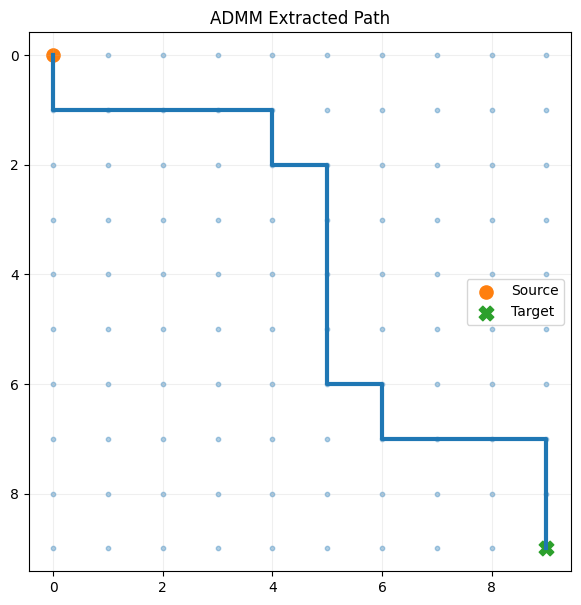

In [12]:
# Visual comparison
plot_grid(coords, dj_path, title="Dijkstra Shortest Path")
plot_grid(coords, opt_path, title="ADMM Extracted Path")


## Interpretation of Results

- **Dijkstra** provides the exact shortest path for the graph.
- **ADMM** solves a constrained numerical optimization version of the route problem.
- The feasibility residual decreases toward zero, showing that the flow constraints are being satisfied.
- The extracted ADMM path can closely match the classical shortest path when the optimization converges well.
- This optimization view is useful because it can be extended to richer constraints such as:
  - toll budgets,
  - congestion penalties,
  - limited energy/fuel,
  - forbidden or risky edges.

## Conclusion

This project demonstrates that the shortest-path problem can be approached in two different ways:

1. a **classical graph algorithm** approach using Dijkstra, and  
2. a **numerical optimization** approach using ADMM and flow-conservation constraints.

The optimization-based formulation is especially valuable because it generalizes naturally to more realistic routing problems with additional constraints.
